# 🩺 Diabetes Health Indicators — Comprehensive Analysis
### BRFSS 2015 Dataset | 253,681 respondents | 22 health indicators

**Goal:** Explore the relationship between lifestyle/health indicators and diabetes status (No Diabetes / Prediabetes / Diabetes), then build predictive models and an interactive dashboard.

---
## Table of Contents
1. [Setup & Data Loading](#1)
2. [Data Overview](#2)
3. [Target Variable Analysis](#3)
4. [Feature Decoding for Readability](#4)
5. [Numeric Feature Distributions](#5)
6. [Age vs Diabetes Status](#6)
7. [Binary Health Indicators](#7)
8. [Ordinal Features (General Health, Education, Income)](#8)
9. [BMI Categories](#9)
10. [Correlation Analysis](#10)
11. [Key Insights Summary](#11)


<a id="1"></a>
## 1 | Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from pathlib import Path

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.facecolor'] = 'white'

FIG_DIR = Path('../reports/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Consistent color scheme for the 3 diabetes classes
TARGET_COLORS = {0: '#2ecc71', 1: '#f1c40f', 2: '#e74c3c'}
TARGET_LABELS = {0: 'No Diabetes', 1: 'Prediabetes', 2: 'Diabetes'}
TARGET_ORDER = [0, 1, 2]

df = pd.read_csv('../data/diabetes_012_health_indicators_BRFSS2015.csv')
print(f"Loaded {df.shape[0]:,} rows and {df.shape[1]} columns")
df.head()

Loaded 253,680 rows and 22 columns


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


<a id="2"></a>
## 2 | Data Overview

In [2]:
rows, cols = df.shape
print(f"Rows: {rows:,} | Columns: {cols}")
print(f"\nColumn dtypes:")
df.dtypes.value_counts()

Rows: 253,680 | Columns: 22

Column dtypes:


float64    22
Name: count, dtype: int64

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [4]:
df.describe().T.style.background_gradient(cmap='Blues').format(precision=2)

,count,mean,std,min,25%,50%,75%,max
Diabetes_012,253680.00,0.30,0.70,0.00,0.00,0.00,0.00,2.00
HighBP,253680.00,0.43,0.49,0.00,0.00,0.00,1.00,1.00
HighChol,253680.00,0.42,0.49,0.00,0.00,0.00,1.00,1.00
CholCheck,253680.00,0.96,0.19,0.00,1.00,1.00,1.00,1.00
BMI,253680.00,28.38,6.61,12.00,24.00,27.00,31.00,98.00
Smoker,253680.00,0.44,0.50,0.00,0.00,0.00,1.00,1.00
Stroke,253680.00,0.04,0.20,0.00,0.00,0.00,0.00,1.00
HeartDiseaseorAttack,253680.00,0.09,0.29,0.00,0.00,0.00,0.00,1.00
PhysActivity,253680.00,0.76,0.43,0.00,1.00,1.00,1.00,1.00
Fruits,253680.00,0.63,0.48,0.00,0.00,1.00,1.00,1.00


**Missing Values Check**

Total missing values: 0


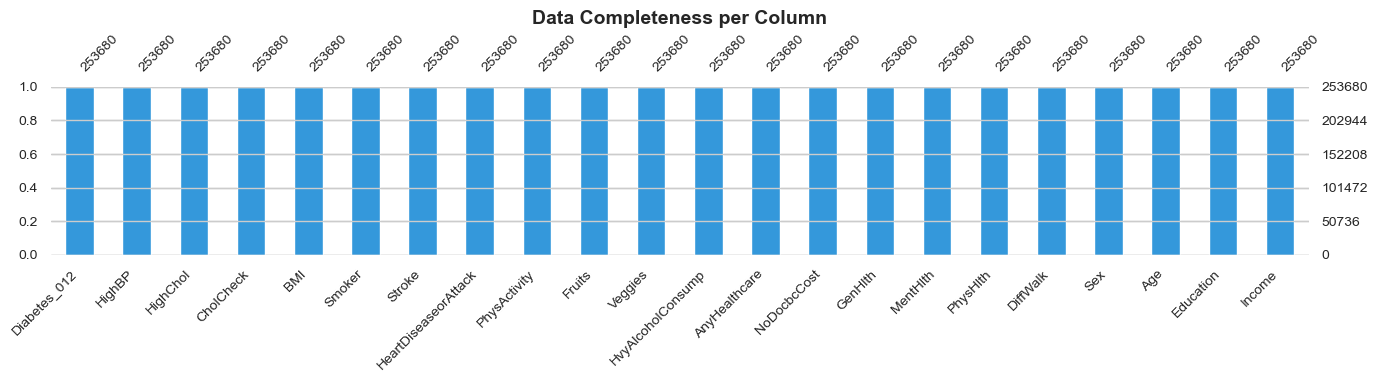

In [5]:
missing = df.isnull().sum()
print(f"Total missing values: {missing.sum()}")

fig = msno.bar(df, color='#3498db', figsize=(14,4), fontsize=10)
plt.title('Data Completeness per Column', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '00_missing_values.png', dpi=120, bbox_inches='tight')
plt.show()

In [6]:
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes:,} ({dupes/len(df)*100:.2f}%)")

Duplicate rows: 23,899 (9.42%)


> **Note:** ~9.4% of rows are exact duplicates across all 22 columns. This is expected for this dataset — with mostly binary/categorical features and ~250K respondents, many people legitimately share identical answer patterns. We'll keep them for EDA (they reflect real survey weight) but will consider this during modeling.

<a id="3"></a>
## 3 | Target Variable Analysis

`Diabetes_012`: **0** = No Diabetes, **1** = Prediabetes, **2** = Diabetes (or borderline diabetes)

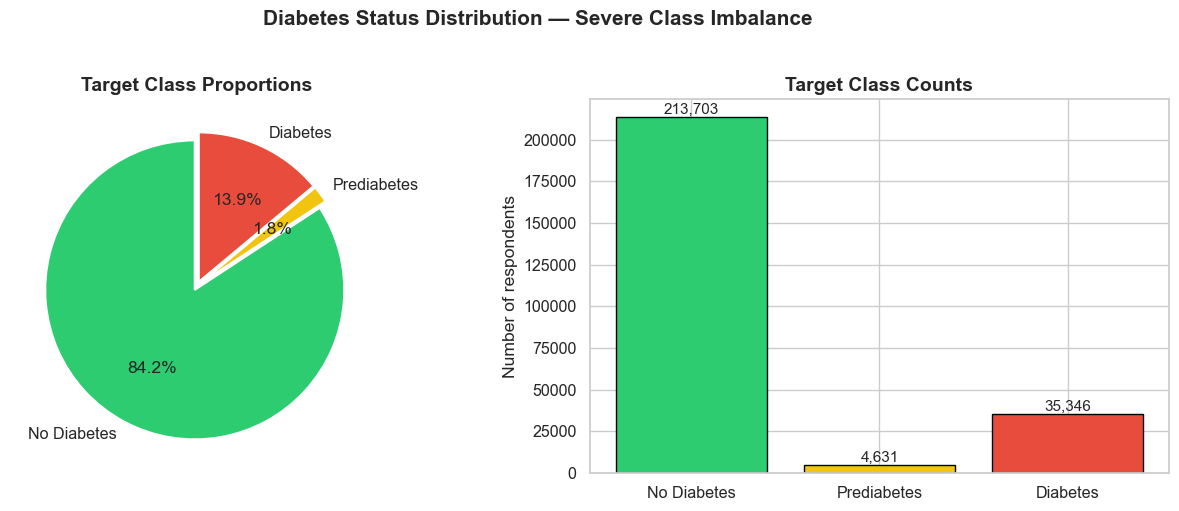

 No Diabetes: 213,703 (84.24%)
 Prediabetes:   4,631 (1.83%)
    Diabetes:  35,346 (13.93%)


In [7]:
counts = df['Diabetes_012'].value_counts().sort_index()
pct = (counts / counts.sum() * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].pie(
    counts, labels=[TARGET_LABELS[i] for i in counts.index],
    autopct='%1.1f%%', colors=[TARGET_COLORS[i] for i in counts.index],
    startangle=90, explode=[0.03]*len(counts),
    wedgeprops={'edgecolor':'white','linewidth':1.5}
)
axes[0].set_title('Target Class Proportions', fontsize=14, fontweight='bold')

bars = axes[1].bar([TARGET_LABELS[i] for i in counts.index], counts.values,
                    color=[TARGET_COLORS[i] for i in counts.index], edgecolor='black')
axes[1].set_title('Target Class Counts', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of respondents')
for bar, val in zip(bars, counts.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, val, f'{val:,}', ha='center', va='bottom', fontsize=11)

plt.suptitle('Diabetes Status Distribution — Severe Class Imbalance', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / '01_target_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

for i in counts.index:
    print(f"{TARGET_LABELS[i]:>12}: {counts[i]:>7,} ({pct[i]}%)")

> **Key takeaway:** The dataset is heavily imbalanced — roughly **84% have no diabetes**, **~2% are prediabetic**, and **~14% have diabetes**. The Prediabetes class is especially rare. This will be a central challenge for modeling (Section in `02_modeling.ipynb`): we'll need class weighting, resampling (SMOTE), and metrics beyond raw accuracy (macro F1, ROC-AUC, recall per class).

<a id="4"></a>
## 4 | Feature Decoding for Readability

Several BRFSS columns are coded as integers per the official codebook. We map them to readable labels in a copy of the data (`df_viz`) used for visualization only — modeling will use the original numeric codes.

In [8]:
# BRFSS codebook mappings
age_map = {
    1: '18-24', 2: '25-29', 3: '30-34', 4: '35-39', 5: '40-44', 6: '45-49',
    7: '50-54', 8: '55-59', 9: '60-64', 10: '65-69', 11: '70-74', 12: '75-79', 13: '80+'
}
genhlth_map = {1: 'Excellent', 2: 'Very Good', 3: 'Good', 4: 'Fair', 5: 'Poor'}
education_map = {
    1: 'None/Kindergarten', 2: 'Elementary', 3: 'Some High School',
    4: 'High School Grad', 5: 'Some College', 6: 'College Grad'
}
income_map = {
    1: '<$10k', 2: '$10-15k', 3: '$15-20k', 4: '$20-25k',
    5: '$25-35k', 6: '$35-50k', 7: '$50-75k', 8: '$75k+'
}

def bmi_category(bmi):
    if bmi < 18.5: return 'Underweight'
    elif bmi < 25: return 'Normal'
    elif bmi < 30: return 'Overweight'
    else: return 'Obese'

df_viz = df.copy()
df_viz['DiabetesStatus'] = df_viz['Diabetes_012'].map(TARGET_LABELS)
df_viz['AgeGroup'] = df_viz['Age'].map(age_map)
df_viz['GenHealth'] = df_viz['GenHlth'].map(genhlth_map)
df_viz['EducationLevel'] = df_viz['Education'].map(education_map)
df_viz['IncomeLevel'] = df_viz['Income'].map(income_map)
df_viz['BMICategory'] = df_viz['BMI'].apply(bmi_category)

df_viz[['Diabetes_012','DiabetesStatus','AgeGroup','GenHealth','EducationLevel','IncomeLevel','BMI','BMICategory']].sample(5, random_state=42)

,Diabetes_012,DiabetesStatus,AgeGroup,GenHealth,EducationLevel,IncomeLevel,BMI,BMICategory
219620,0.0,No Diabetes,50-54,Good,High School Grad,$10-15k,21.0,Normal
132821,0.0,No Diabetes,80+,Good,College Grad,$35-50k,28.0,Overweight
151862,0.0,No Diabetes,18-24,Excellent,High School Grad,$50-75k,24.0,Normal
139717,0.0,No Diabetes,25-29,Very Good,High School Grad,$50-75k,27.0,Overweight
239235,0.0,No Diabetes,55-59,Fair,Some High School,$10-15k,31.0,Obese


<a id="5"></a>
## 5 | Numeric Feature Distributions

`BMI`, `MentHlth` (days of poor mental health in past 30 days), and `PhysHlth` (days of poor physical health in past 30 days) are the only continuous/count features. We compare their distributions across the three diabetes classes.

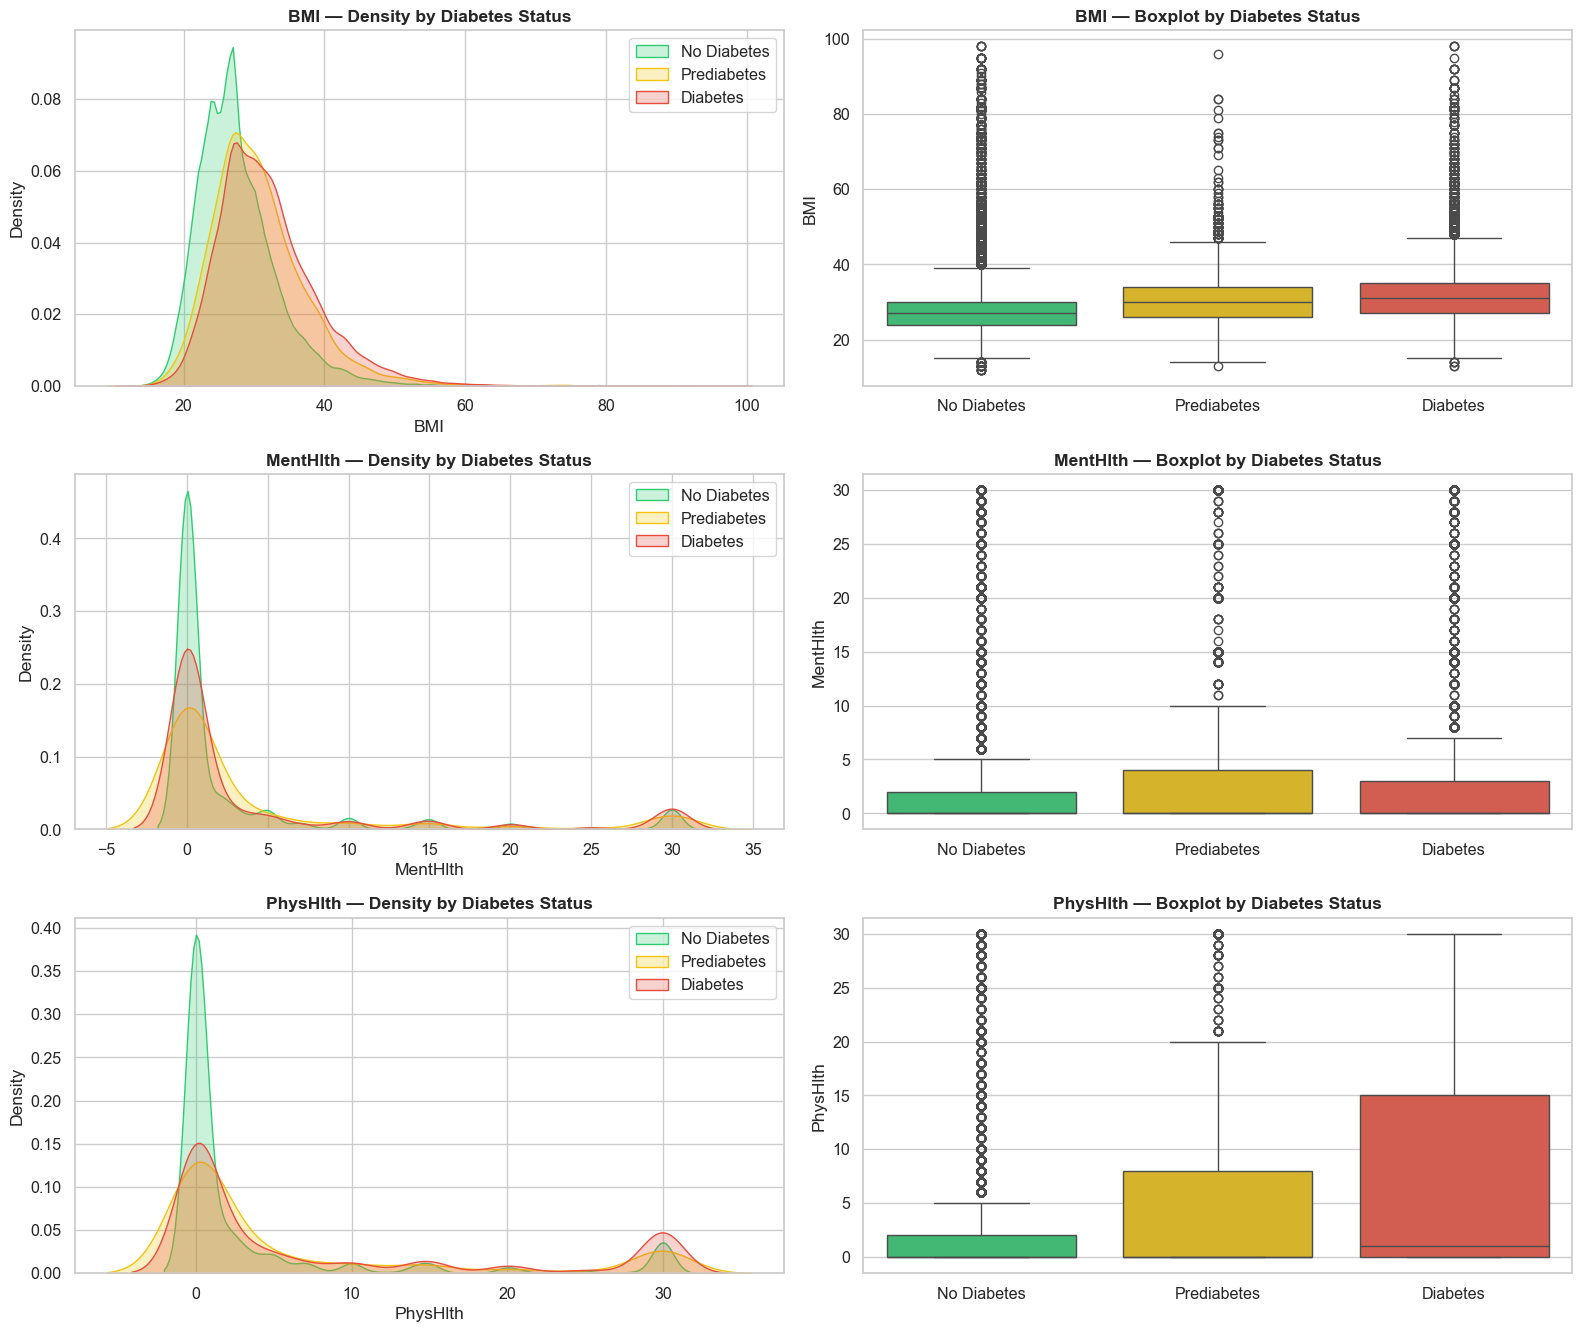

In [9]:
numeric_feats = ['BMI', 'MentHlth', 'PhysHlth']

fig, axes = plt.subplots(len(numeric_feats), 2, figsize=(16, 4.5*len(numeric_feats)))

for i, feat in enumerate(numeric_feats):
    ax_hist, ax_box = axes[i]

    for cls in TARGET_ORDER:
        subset = df_viz.loc[df_viz['Diabetes_012'] == cls, feat]
        sns.kdeplot(subset, ax=ax_hist, label=TARGET_LABELS[cls],
                    color=TARGET_COLORS[cls], fill=True, alpha=0.25, common_norm=False)
    ax_hist.set_title(f'{feat} — Density by Diabetes Status', fontweight='bold')
    ax_hist.set_xlabel(feat)
    ax_hist.legend()

    sns.boxplot(data=df_viz, x='DiabetesStatus', y=feat, ax=ax_box,
                order=[TARGET_LABELS[c] for c in TARGET_ORDER],
                palette={TARGET_LABELS[c]: TARGET_COLORS[c] for c in TARGET_ORDER},
                hue='DiabetesStatus', legend=False)
    ax_box.set_title(f'{feat} — Boxplot by Diabetes Status', fontweight='bold')
    ax_box.set_xlabel('')

plt.tight_layout()
plt.savefig(FIG_DIR / '02_numeric_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

In [10]:
df_viz.groupby('DiabetesStatus')[numeric_feats].median().loc[[TARGET_LABELS[c] for c in TARGET_ORDER]]

,BMI,MentHlth,PhysHlth
DiabetesStatus,,,
No Diabetes,27.0,0.0,0.0
Prediabetes,30.0,0.0,0.0
Diabetes,31.0,0.0,1.0


> **Observation:** `BMI` shows a clear rightward shift for the Diabetes group — higher BMI is strongly associated with diabetes/prediabetes. `MentHlth` and `PhysHlth` are heavily right-skewed (most respondents report 0 bad days), but the Diabetes group has a noticeably heavier tail, indicating more reported unhealthy days.

<a id="6"></a>
## 6 | Age vs Diabetes Status

`Age` is coded in 13 brackets (1 = 18-24 ... 13 = 80+). We look at how diabetes prevalence changes across age groups.

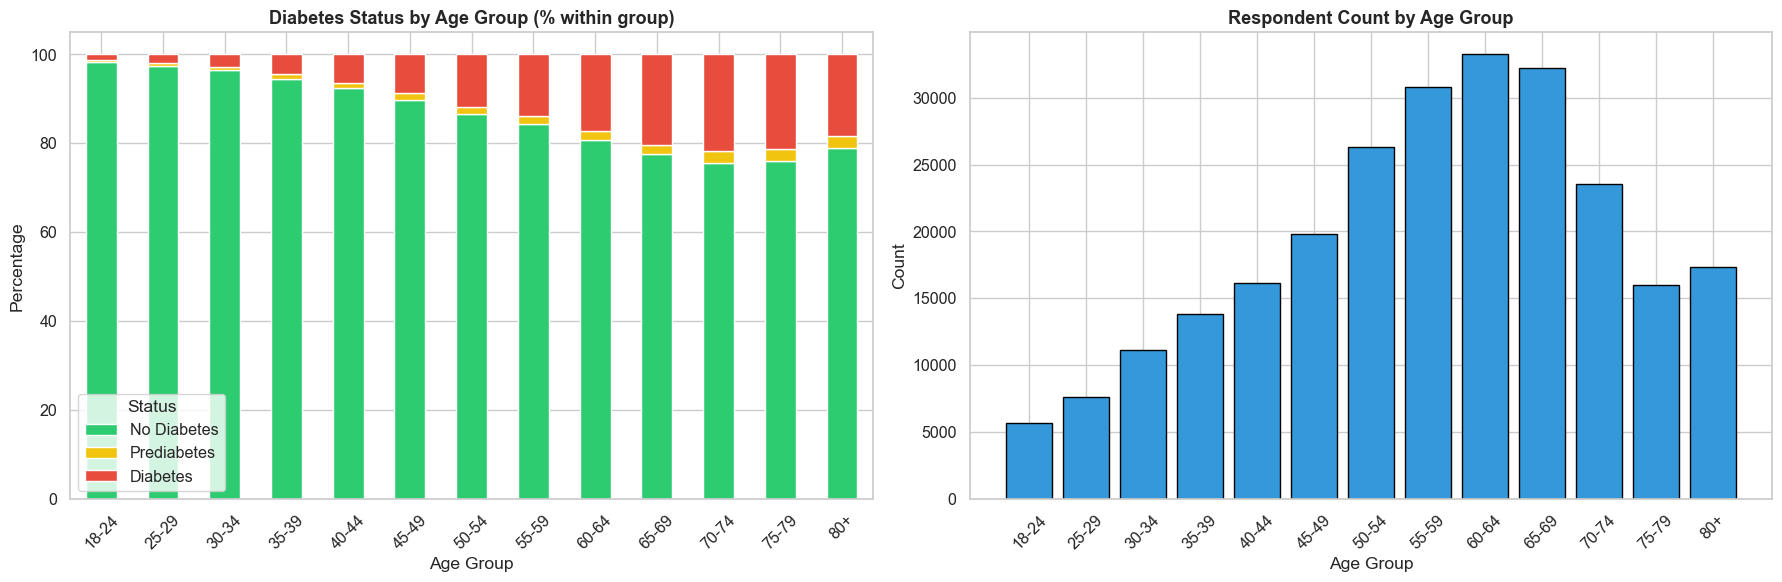

In [11]:
age_order = [age_map[i] for i in range(1, 14)]
age_diab = pd.crosstab(df_viz['AgeGroup'], df_viz['DiabetesStatus'], normalize='index') * 100
age_diab = age_diab.reindex(age_order)[[TARGET_LABELS[c] for c in TARGET_ORDER]]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

age_diab.plot(kind='bar', stacked=True, color=[TARGET_COLORS[c] for c in TARGET_ORDER],
               ax=axes[0], edgecolor='white')
axes[0].set_title('Diabetes Status by Age Group (% within group)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Percentage')
axes[0].set_xlabel('Age Group')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Status')

age_counts = df_viz['AgeGroup'].value_counts().reindex(age_order)
axes[1].bar(age_order, age_counts.values, color='#3498db', edgecolor='black')
axes[1].set_title('Respondent Count by Age Group', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('Age Group')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(FIG_DIR / '03_age_vs_diabetes.png', dpi=120, bbox_inches='tight')
plt.show()

> **Observation:** Diabetes prevalence climbs steadily with age — from under 5% in the 18-24 bracket to roughly a quarter of respondents aged 60+. Prediabetes follows a similar but much smaller trend. Age is one of the strongest non-modifiable risk factors in this dataset.

<a id="7"></a>
## 7 | Binary Health Indicators

For each binary feature (1 = Yes / 0 = No), we compute the proportion of "Yes" responses within each diabetes class — a direct view of how strongly each lifestyle/health factor co-occurs with diabetes status.

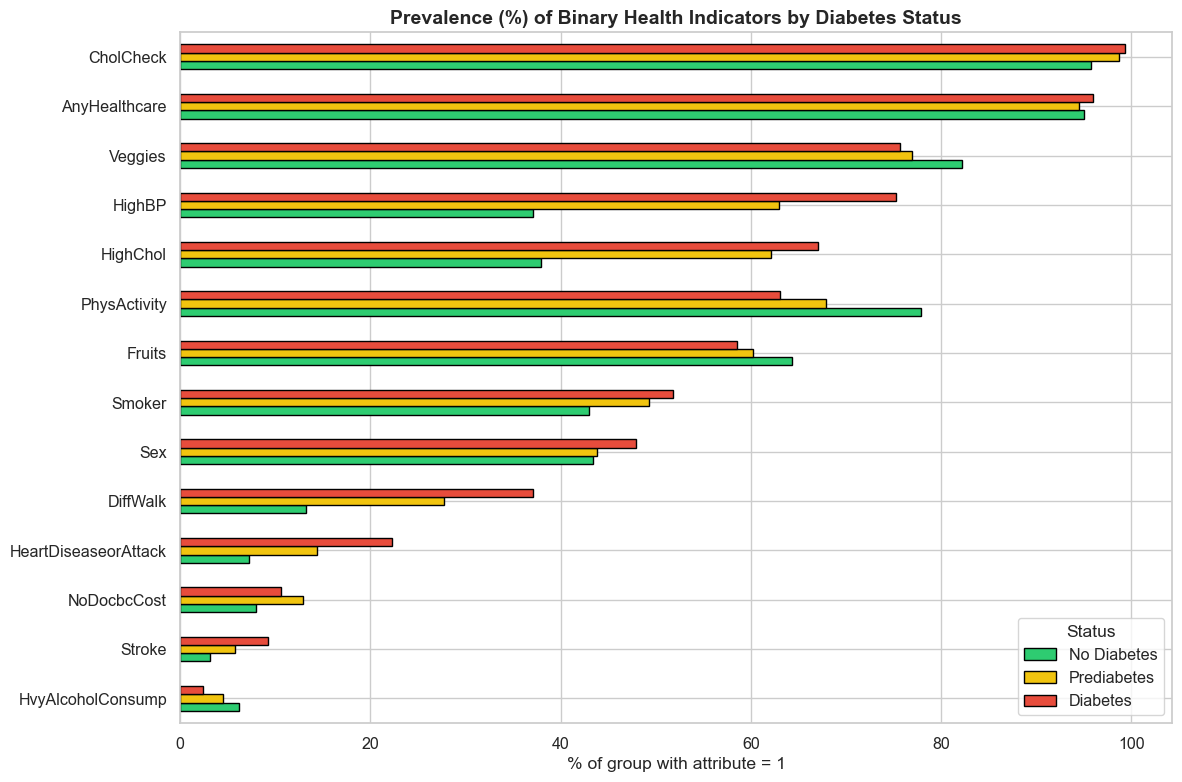

,No Diabetes,Prediabetes,Diabetes
HvyAlcoholConsump,6.2,4.5,2.4
Stroke,3.2,5.7,9.2
NoDocbcCost,8.0,12.9,10.6
HeartDiseaseorAttack,7.2,14.3,22.3
DiffWalk,13.2,27.7,37.1
Sex,43.4,43.8,47.9
Smoker,43.0,49.3,51.8
Fruits,64.3,60.2,58.5
PhysActivity,77.9,67.8,63.1
HighChol,37.9,62.1,67.0


In [12]:
binary_feats = ['HighBP','HighChol','CholCheck','Smoker','Stroke','HeartDiseaseorAttack',
                'PhysActivity','Fruits','Veggies','HvyAlcoholConsump','AnyHealthcare',
                'NoDocbcCost','DiffWalk','Sex']

prop_df = df_viz.groupby('Diabetes_012')[binary_feats].mean().T * 100
prop_df.columns = [TARGET_LABELS[c] for c in prop_df.columns]
prop_df = prop_df.sort_values('Diabetes', ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
prop_df[[TARGET_LABELS[c] for c in TARGET_ORDER]].plot(
    kind='barh', ax=ax, color=[TARGET_COLORS[c] for c in TARGET_ORDER], edgecolor='black')
ax.set_title('Prevalence (%) of Binary Health Indicators by Diabetes Status', fontsize=14, fontweight='bold')
ax.set_xlabel('% of group with attribute = 1')
ax.legend(title='Status')
plt.tight_layout()
plt.savefig(FIG_DIR / '04_binary_features_by_target.png', dpi=120, bbox_inches='tight')
plt.show()

prop_df.round(1)

> **Observation:** `HighBP`, `HighChol`, `DiffWalk` (difficulty walking), and `HeartDiseaseorAttack` show the largest gaps between the No-Diabetes and Diabetes groups — all roughly 2x more prevalent among diabetics. Protective behaviors like `PhysActivity`, `Fruits`, and `Veggies` are modestly *less* common in the Diabetes group. `Sex` and `AnyHealthcare` show little difference across groups.

<a id="8"></a>
## 8 | Ordinal Features: General Health, Education, Income

`GenHlth` is self-reported general health (Excellent → Poor). `Education` and `Income` are socioeconomic indicators. We look at the diabetes status breakdown within each category.

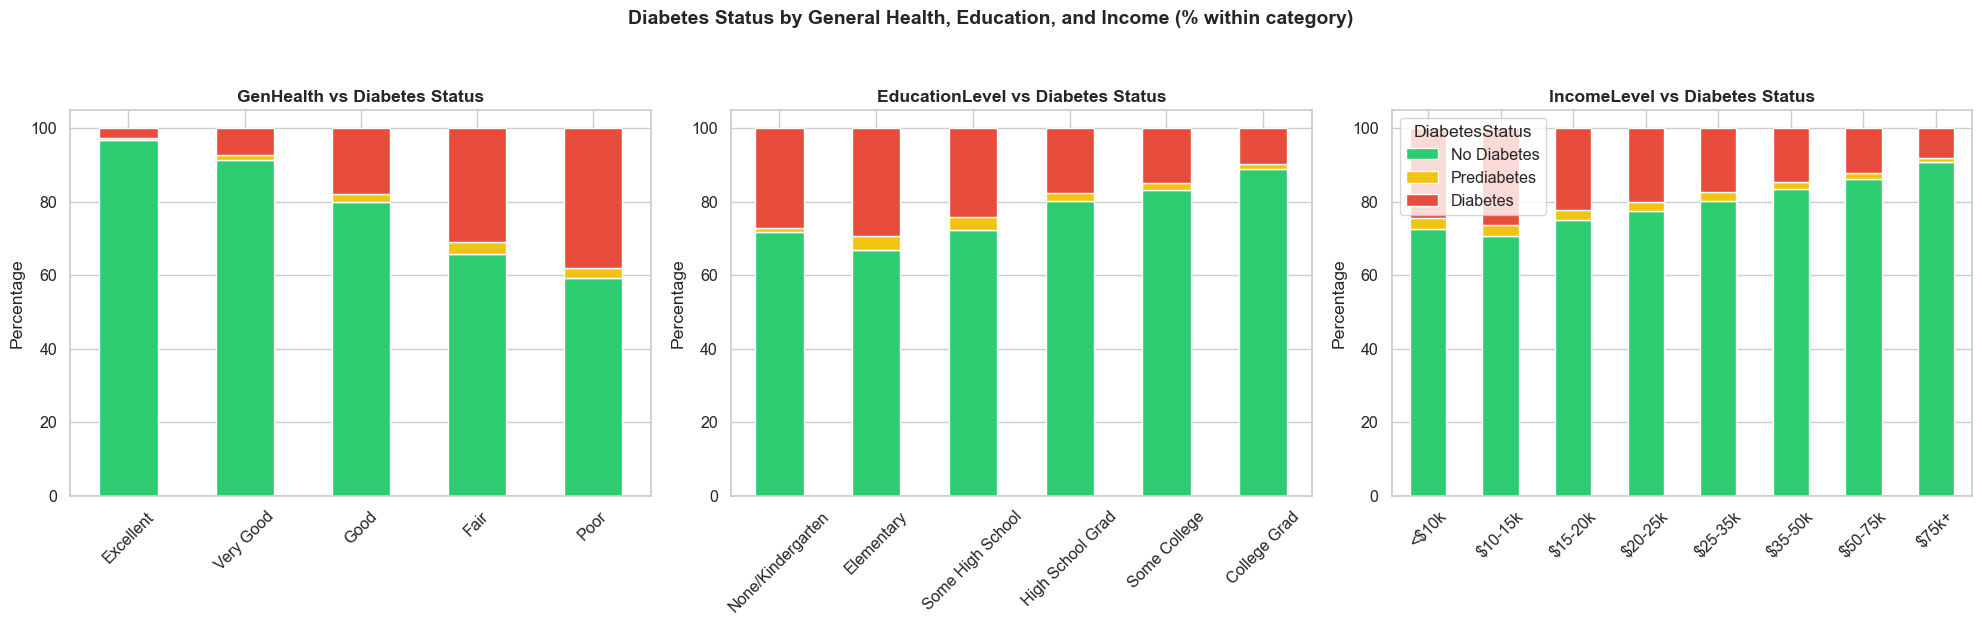

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

panels = [
    ('GenHealth', list(genhlth_map.values())),
    ('EducationLevel', list(education_map.values())),
    ('IncomeLevel', list(income_map.values())),
]

for ax, (col, order_keys) in zip(axes, panels):
    ct = pd.crosstab(df_viz[col], df_viz['DiabetesStatus'], normalize='index') * 100
    ct = ct.reindex(order_keys)[[TARGET_LABELS[c] for c in TARGET_ORDER]]
    ct.plot(kind='bar', stacked=True, color=[TARGET_COLORS[c] for c in TARGET_ORDER],
            ax=ax, edgecolor='white', legend=(ax is axes[-1]))
    ax.set_title(f'{col} vs Diabetes Status', fontweight='bold')
    ax.set_ylabel('Percentage')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Diabetes Status by General Health, Education, and Income (% within category)',
              fontsize=14, fontweight='bold', y=1.04)
plt.tight_layout()
plt.savefig(FIG_DIR / '05_ordinal_features_vs_target.png', dpi=120, bbox_inches='tight')
plt.show()

> **Observation:** `GenHlth` shows the strongest gradient of all three — among respondents reporting "Poor" general health, over 35% have diabetes, vs. under 5% for "Excellent". Education and income show milder but consistent gradients: lower education/income brackets have higher diabetes prevalence, reflecting well-documented socioeconomic health disparities.

<a id="9"></a>
## 9 | BMI Categories vs Diabetes Status

Standard WHO BMI categories: Underweight (<18.5), Normal (18.5-25), Overweight (25-30), Obese (30+).

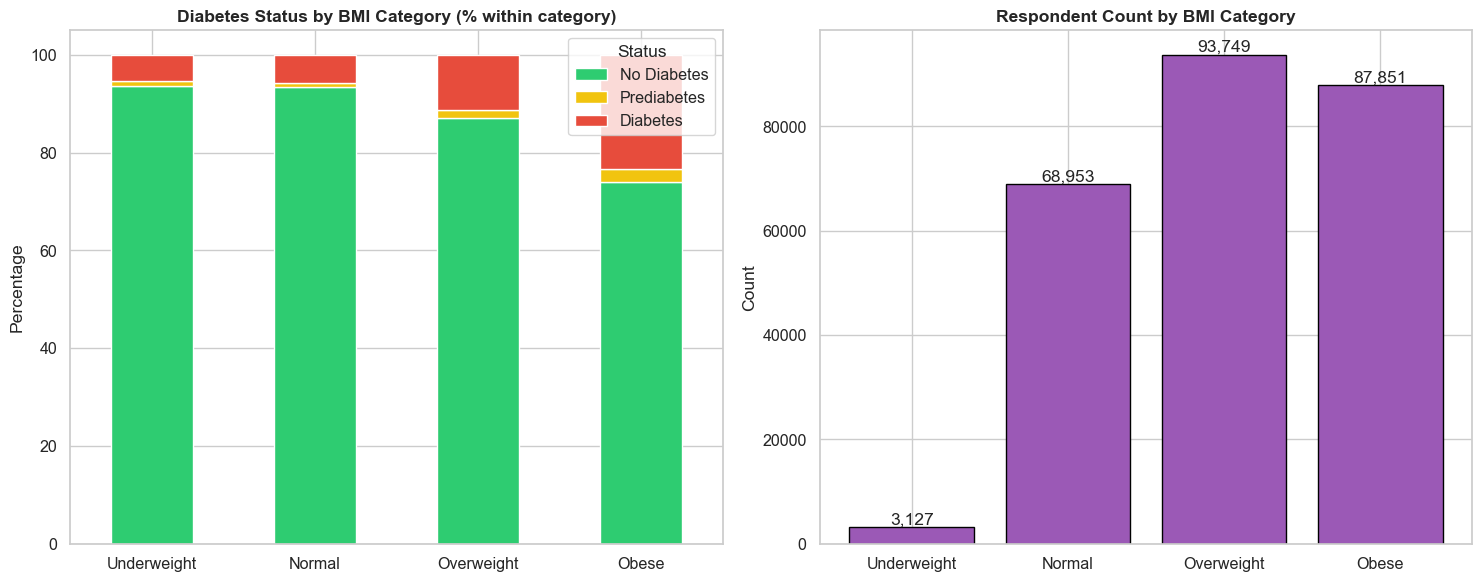

DiabetesStatus,No Diabetes,Prediabetes,Diabetes
BMICategory,,,
Underweight,93.7,0.9,5.4
Normal,93.3,1.0,5.7
Overweight,87.0,1.6,11.4
Obese,73.9,2.7,23.4


In [14]:
bmi_order = ['Underweight', 'Normal', 'Overweight', 'Obese']
bmi_ct = pd.crosstab(df_viz['BMICategory'], df_viz['DiabetesStatus'], normalize='index') * 100
bmi_ct = bmi_ct.reindex(bmi_order)[[TARGET_LABELS[c] for c in TARGET_ORDER]]

bmi_counts = df_viz['BMICategory'].value_counts().reindex(bmi_order)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

bmi_ct.plot(kind='bar', stacked=True, color=[TARGET_COLORS[c] for c in TARGET_ORDER],
            ax=axes[0], edgecolor='white')
axes[0].set_title('Diabetes Status by BMI Category (% within category)', fontweight='bold')
axes[0].set_ylabel('Percentage')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Status')

axes[1].bar(bmi_order, bmi_counts.values, color='#9b59b6', edgecolor='black')
axes[1].set_title('Respondent Count by BMI Category', fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate(bmi_counts.values):
    axes[1].text(i, v, f'{v:,}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig(FIG_DIR / '06_bmi_category_vs_target.png', dpi=120, bbox_inches='tight')
plt.show()

bmi_ct.round(1)

> **Observation:** Diabetes prevalence rises sharply with BMI category — from ~5% in Underweight/Normal to ~20%+ in Obese. Most respondents fall into Overweight or Obese categories, underscoring BMI as one of the most actionable risk factors.

<a id="10"></a>
## 10 | Correlation Analysis

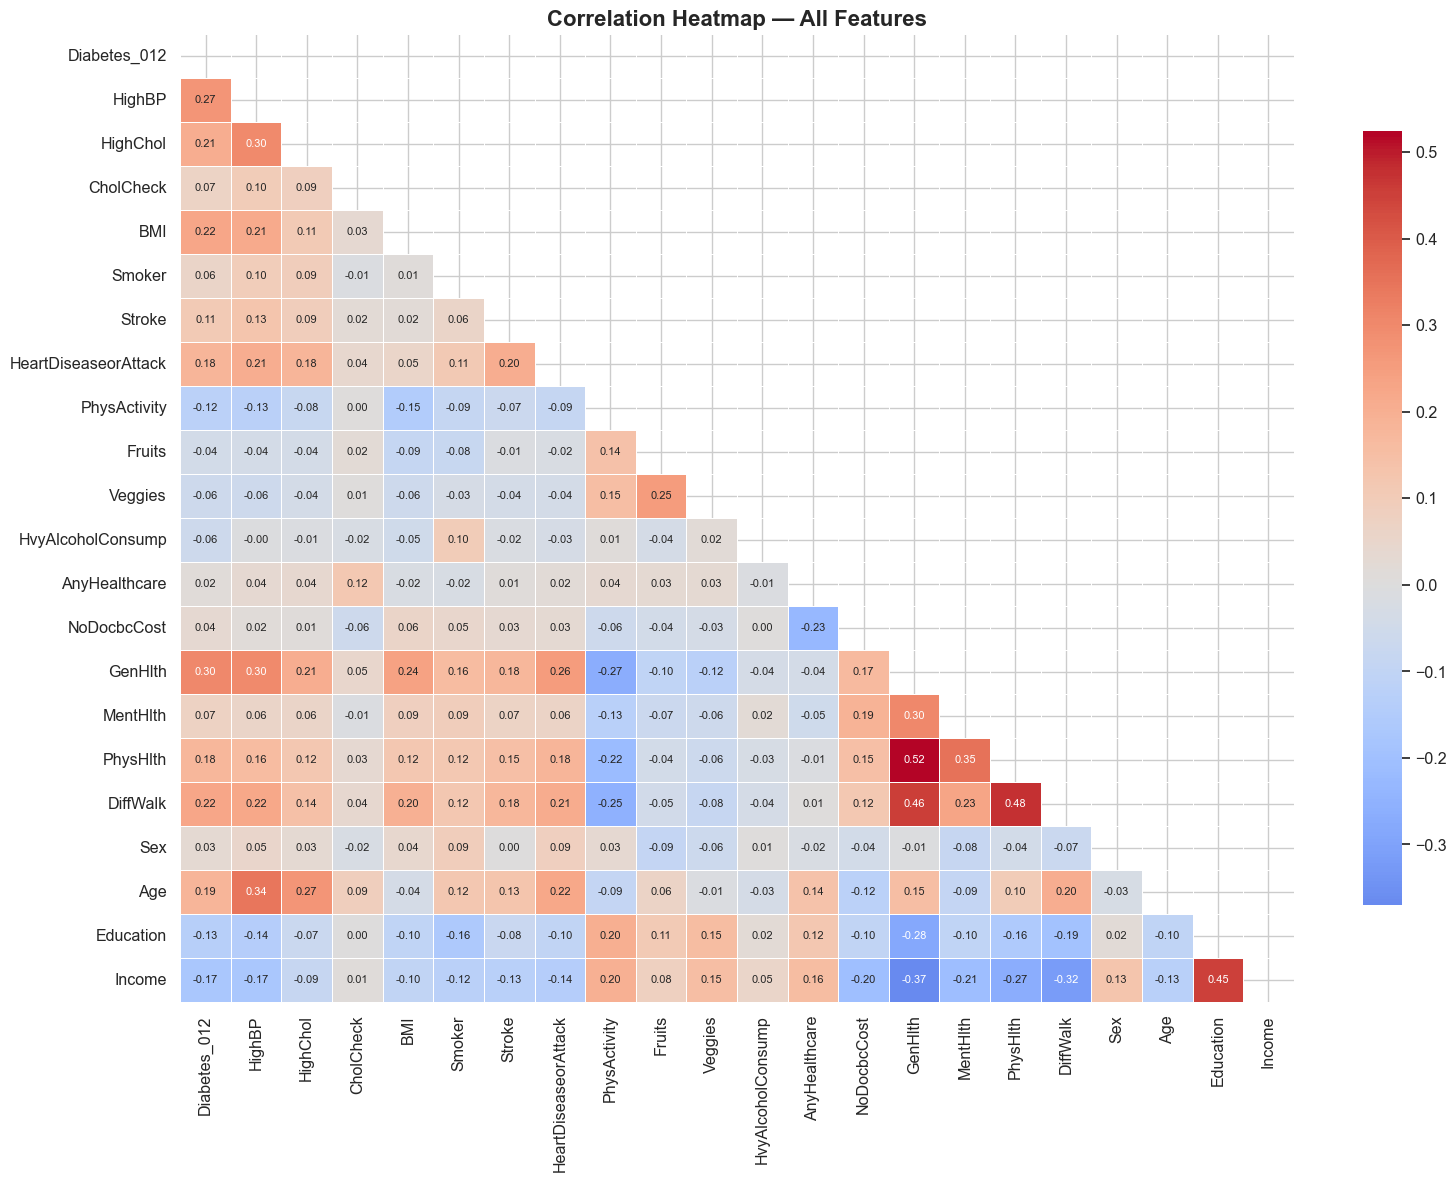

In [15]:
plt.figure(figsize=(16, 12))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, cbar_kws={'shrink': 0.8}, annot_kws={'size': 8})
plt.title('Correlation Heatmap — All Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '07_correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

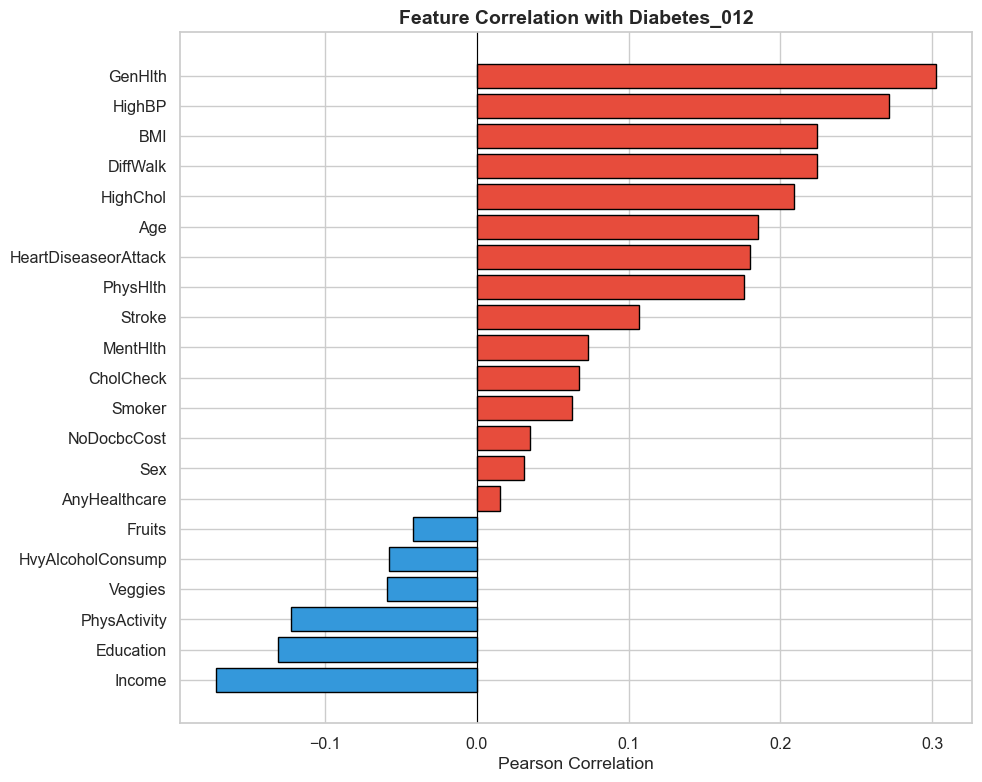

GenHlth                 0.302587
HighBP                  0.271596
BMI                     0.224379
DiffWalk                0.224239
HighChol                0.209085
Age                     0.185026
HeartDiseaseorAttack    0.180272
PhysHlth                0.176287
Stroke                  0.107179
MentHlth                0.073507
CholCheck               0.067546
Smoker                  0.062914
NoDocbcCost             0.035436
Sex                     0.031040
AnyHealthcare           0.015410
Fruits                 -0.042192
HvyAlcoholConsump      -0.057882
Veggies                -0.058972
PhysActivity           -0.121947
Education              -0.130517
Income                 -0.171483
Name: Diabetes_012, dtype: float64

In [16]:
target_corr = df.corr()['Diabetes_012'].drop('Diabetes_012').sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in target_corr.values]
ax.barh(target_corr.index, target_corr.values, color=colors, edgecolor='black')
ax.set_title('Feature Correlation with Diabetes_012', fontsize=14, fontweight='bold')
ax.set_xlabel('Pearson Correlation')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig(FIG_DIR / '08_target_correlations.png', dpi=120, bbox_inches='tight')
plt.show()

target_corr.sort_values(ascending=False)

> **Observation:** `GenHlth`, `HighBP`, `BMI`, `DiffWalk`, and `HighChol` show the strongest positive correlations with diabetes status, while `PhysActivity`, `Education`, and `Income` show the strongest negative (protective) correlations. No pair of features is so highly correlated (>0.7) as to suggest severe multicollinearity, though `GenHlth`/`PhysHlth`/`DiffWalk` are moderately related (all reflect overall health).

<a id="10.5"></a>
## 10.5 | Statistical Significance Testing

Correlation captures linear association, but our target is categorical and several features are nominal/ordinal. To rigorously rank risk factors we run:
- **Chi-square test of independence + Cramér's V** for categorical/ordinal features (HighBP, HighChol, GenHlth, Age, Education, Income, etc.)
- **Kruskal-Wallis H-test + epsilon-squared** for the continuous/count features (BMI, MentHlth, PhysHlth)

With n ≈ 253,680, p-values will be vanishingly small for almost everything — so we focus on **effect size** (Cramér's V / epsilon-squared) to judge practical importance, not just statistical significance.

In [17]:
from scipy.stats import chi2_contingency, kruskal

n = len(df)
results = []

cat_like_feats = ['HighBP','HighChol','CholCheck','Smoker','Stroke','HeartDiseaseorAttack',
                   'PhysActivity','Fruits','Veggies','HvyAlcoholConsump','AnyHealthcare',
                   'NoDocbcCost','DiffWalk','Sex','GenHlth','Education','Income','Age']

for feat in cat_like_feats:
    contingency = pd.crosstab(df[feat], df['Diabetes_012'])
    chi2, p, dof, _ = chi2_contingency(contingency)
    r, k = contingency.shape
    cramers_v = np.sqrt((chi2 / n) / (min(r - 1, k - 1)))
    results.append({'Feature': feat, 'Test': 'Chi-square', 'p-value': p, 'Effect Size': cramers_v, 'Effect Type': "Cramér's V"})

num_feats_test = ['BMI', 'MentHlth', 'PhysHlth']
for feat in num_feats_test:
    groups = [df.loc[df['Diabetes_012'] == c, feat] for c in TARGET_ORDER]
    h_stat, p = kruskal(*groups)
    k_groups = len(groups)
    eps_sq = (h_stat - k_groups + 1) / (n - k_groups)
    results.append({'Feature': feat, 'Test': 'Kruskal-Wallis', 'p-value': p, 'Effect Size': eps_sq, 'Effect Type': 'Epsilon-squared'})

results_df = pd.DataFrame(results).sort_values('Effect Size', ascending=False).reset_index(drop=True)
results_df['p-value'] = results_df['p-value'].apply(lambda x: '<0.0001' if x < 0.0001 else f'{x:.4f}')

results_df.style.background_gradient(subset=['Effect Size'], cmap='Oranges').format({'Effect Size': '{:.4f}'})

,Feature,Test,p-value,Effect Size,Effect Type
0,HighBP,Chi-square,<0.0001,0.2722,Cramér's V
1,DiffWalk,Chi-square,<0.0001,0.2244,Cramér's V
2,GenHlth,Chi-square,<0.0001,0.2186,Cramér's V
3,HighChol,Chi-square,<0.0001,0.2107,Cramér's V
4,HeartDiseaseorAttack,Chi-square,<0.0001,0.1803,Cramér's V
5,Age,Chi-square,<0.0001,0.1379,Cramér's V
6,Income,Chi-square,<0.0001,0.1241,Cramér's V
7,PhysActivity,Chi-square,<0.0001,0.1222,Cramér's V
8,Stroke,Chi-square,<0.0001,0.1072,Cramér's V
9,Education,Chi-square,<0.0001,0.0948,Cramér's V


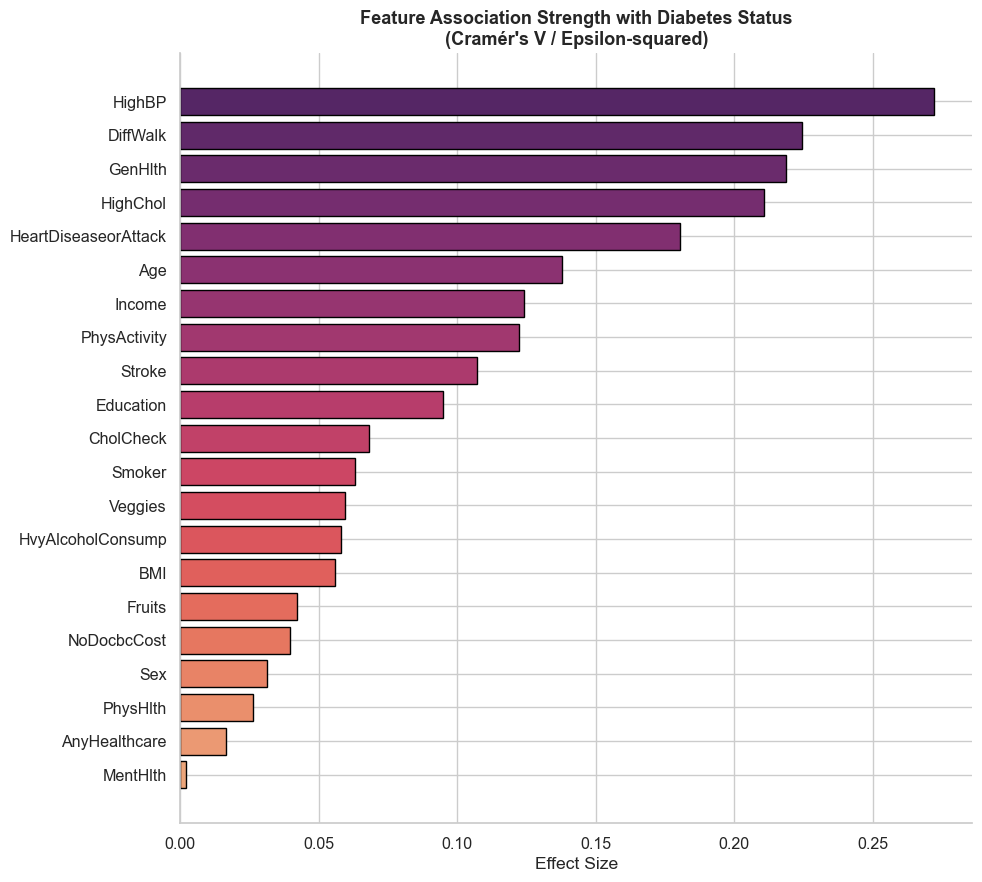

In [18]:
fig, ax = plt.subplots(figsize=(10, 9))
plot_df = results_df.sort_values('Effect Size')
colors = sns.color_palette('flare', len(plot_df))
ax.barh(plot_df['Feature'], plot_df['Effect Size'], color=colors, edgecolor='black')
ax.set_title('Feature Association Strength with Diabetes Status\n(Cramér\'s V / Epsilon-squared)', fontsize=13, fontweight='bold')
ax.set_xlabel('Effect Size')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / '09_effect_sizes.png', dpi=120, bbox_inches='tight')
plt.show()

> **Observation:** Ranked by effect size, `HighBP` (Cramér's V ≈ 0.27) edges out `DiffWalk` (≈0.22), `GenHlth` (≈0.22), `HighChol` (≈0.21), and `HeartDiseaseorAttack` (≈0.18) as the single strongest associated factor — a slightly different ordering than the linear-correlation view, since chi-square captures non-linear/non-monotonic associations too. `Age`, `Income`, `PhysActivity`, `Stroke`, and `Education` round out the top 10. Effect sizes are mostly "small-to-moderate" (Cramér's V 0.05-0.27), typical for population health survey data — no single feature dominates, so models will need to combine many weak-to-moderate signals.

<a id="10.6"></a>
## 10.6 | Executive Summary Dashboard

A single combined view of the headline findings — useful as a quick-reference and for reuse in the Streamlit dashboard.

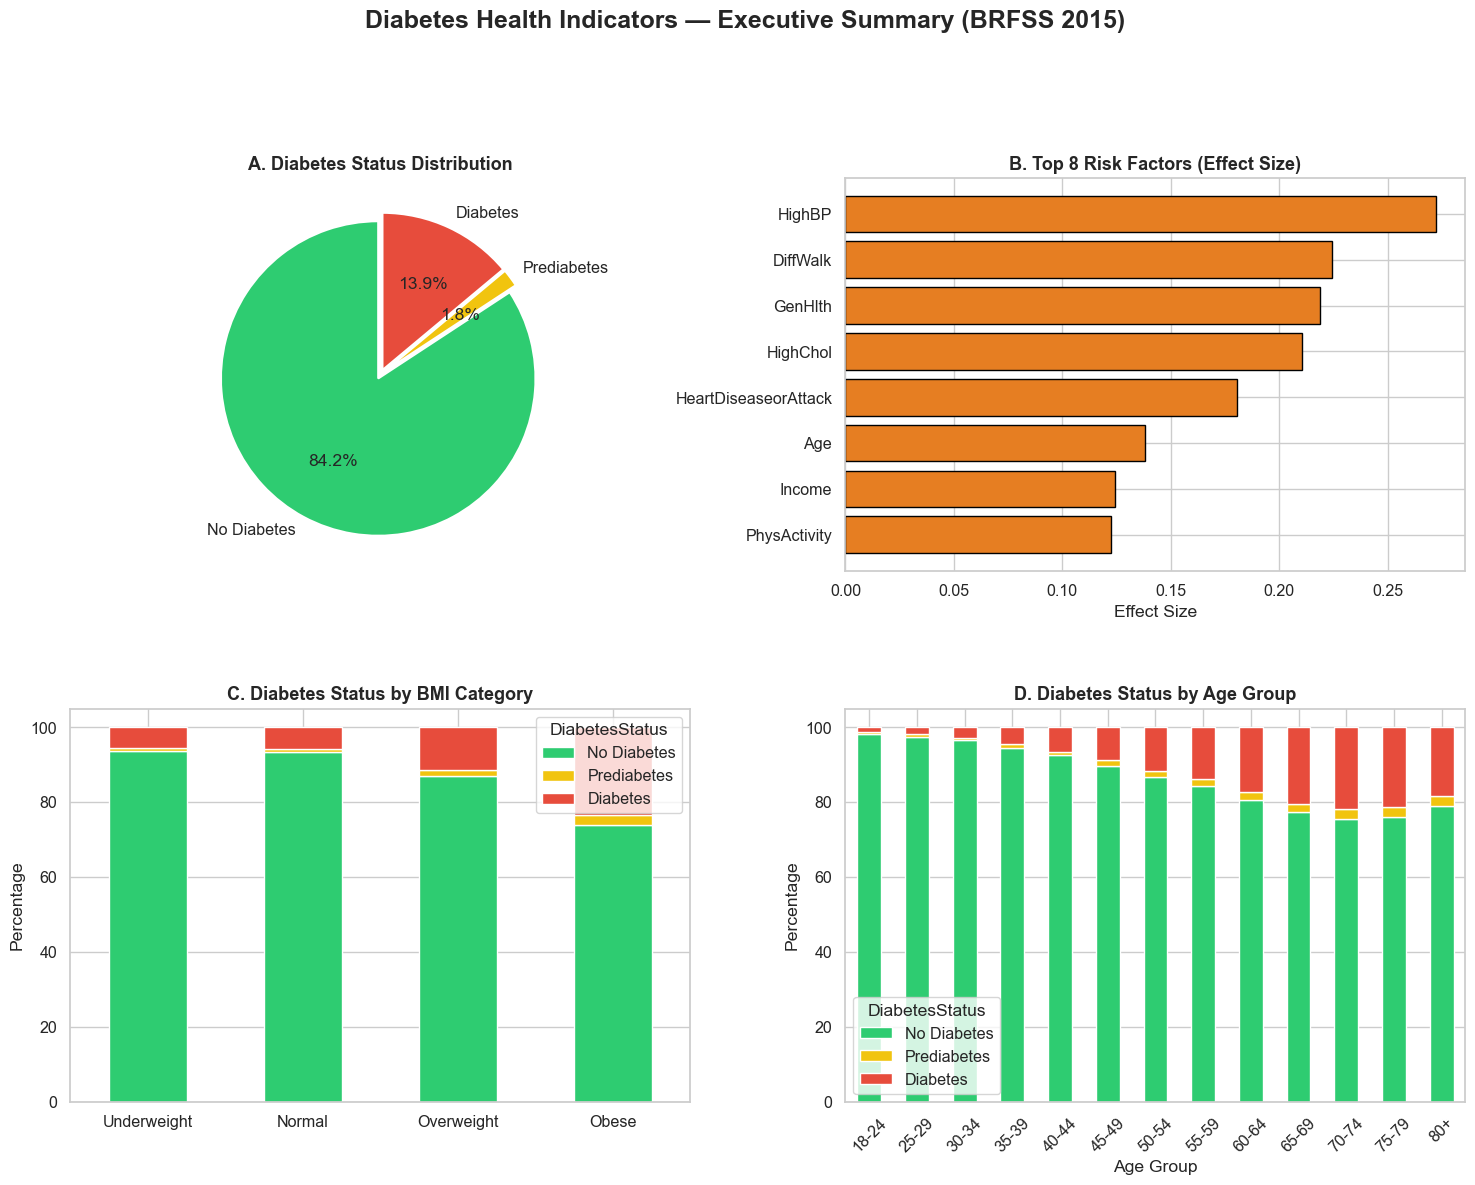

In [19]:
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.25)

# Panel 1: Target distribution pie
ax1 = fig.add_subplot(gs[0, 0])
ax1.pie(counts, labels=[TARGET_LABELS[i] for i in counts.index], autopct='%1.1f%%',
        colors=[TARGET_COLORS[i] for i in counts.index], startangle=90,
        explode=[0.03]*len(counts), wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax1.set_title('A. Diabetes Status Distribution', fontsize=13, fontweight='bold')

# Panel 2: Top effect sizes
ax2 = fig.add_subplot(gs[0, 1])
top_feats = results_df.head(8).sort_values('Effect Size')
ax2.barh(top_feats['Feature'], top_feats['Effect Size'], color='#e67e22', edgecolor='black')
ax2.set_title('B. Top 8 Risk Factors (Effect Size)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Effect Size')

# Panel 3: BMI category
ax3 = fig.add_subplot(gs[1, 0])
bmi_ct.plot(kind='bar', stacked=True, color=[TARGET_COLORS[c] for c in TARGET_ORDER],
            ax=ax3, edgecolor='white', legend=True)
ax3.set_title('C. Diabetes Status by BMI Category', fontsize=13, fontweight='bold')
ax3.set_ylabel('Percentage')
ax3.set_xlabel('')
ax3.tick_params(axis='x', rotation=0)

# Panel 4: Age group
ax4 = fig.add_subplot(gs[1, 1])
age_diab.plot(kind='bar', stacked=True, color=[TARGET_COLORS[c] for c in TARGET_ORDER],
               ax=ax4, edgecolor='white', legend=True)
ax4.set_title('D. Diabetes Status by Age Group', fontsize=13, fontweight='bold')
ax4.set_ylabel('Percentage')
ax4.set_xlabel('Age Group')
ax4.tick_params(axis='x', rotation=45)

fig.suptitle('Diabetes Health Indicators — Executive Summary (BRFSS 2015)', fontsize=18, fontweight='bold', y=1.02)
plt.savefig(FIG_DIR / '10_executive_summary.png', dpi=120, bbox_inches='tight')
plt.show()

<a id="11"></a>
## 11 | Executive Summary

<div style="background-color:#254E58; color:white; padding:18px 22px; border-radius:8px; font-family:Georgia;">
<b>Diabetes Health Indicators — BRFSS 2015</b><br>
253,680 respondents &nbsp;|&nbsp; 22 indicators &nbsp;|&nbsp; 3-class target (No Diabetes / Prediabetes / Diabetes)
</div>

### Dataset Quality
| Check | Result |
|---|---|
| Missing values | 0 (fully complete) |
| Duplicate rows | 9.4% (~23,899) — plausible given limited categorical combinations; retained for EDA |
| Feature types | 1 continuous (BMI), 2 count (MentHlth, PhysHlth), 19 binary/ordinal |

### Target Distribution — Severe Class Imbalance
| Class | Count | Share |
|---|---|---|
| No Diabetes | 213,703 | 84.2% |
| Prediabetes | 4,631 | 1.8% |
| Diabetes | 35,346 | 13.9% |

The Prediabetes class is **~46x smaller** than the No-Diabetes class. Accuracy alone would be a misleading metric — any model that always predicts "No Diabetes" scores 84.2%.

### Top Risk Factors (ranked by effect size, Cramér's V / epsilon-squared)
| Rank | Feature | Effect Size | Interpretation |
|---|---|---|---|
| 1 | `HighBP` | 0.272 | Diabetics are ~2x more likely to have high blood pressure |
| 2 | `DiffWalk` | 0.224 | Difficulty walking nearly 3x more common in diabetics (37% vs 13%) |
| 3 | `GenHlth` | 0.219 | "Poor" self-rated health → 35%+ diabetes prevalence vs <5% for "Excellent" |
| 4 | `HighChol` | 0.211 | High cholesterol ~30 pts more prevalent in diabetics |
| 5 | `HeartDiseaseorAttack` | 0.180 | 3x more common in diabetics (22% vs 7%) |
| 6 | `Age` | 0.138 | Prevalence rises from <5% (18-24) to ~25% (60+) |
| 7 | `Income` | 0.124 | Lower income brackets show higher prevalence (socioeconomic gradient) |
| 8 | `PhysActivity` | 0.122 | Protective — less common among diabetics (63% vs 78%) |
| 9 | `Stroke` | 0.107 | ~3x more common in diabetics (9.2% vs 3.2%) |
| 10 | `Education` | 0.095 | Lower education brackets show higher prevalence |

> `BMI` ranks lower on this particular scale (epsilon-squared ≈ 0.056, #15 overall) — note Cramér's V and epsilon-squared aren't perfectly comparable across test types, and BMI's *practical* signal remains strong: median BMI rises 27 → 30 → 31 across No Diabetes → Prediabetes → Diabetes, and the Obese category shows 23.4% diabetes prevalence vs ~5% for Normal/Underweight.

### Highest- and Lowest-Risk Population Segments
- **Highest risk:** Obese, age 60+, Poor self-rated health, difficulty walking, existing HighBP/HighChol/HeartDisease — segments here show 25-40% diabetes prevalence.
- **Lowest risk:** Normal/Underweight BMI, age 18-24, Excellent self-rated health, physically active — segments here show <5% diabetes prevalence.

### Modeling Implications (→ `02_modeling.ipynb`)
1. **Imbalance handling is critical** — use `class_weight='balanced'`, SMOTE/SMOTENC, and/or threshold tuning. Evaluate with macro-F1, balanced accuracy, per-class recall, and one-vs-rest ROC-AUC — not raw accuracy.
2. **Stratified splits** to preserve the 84/2/14 ratio across train/validation/test.
3. **Priority features** for engineering and importance analysis: `HighBP`, `DiffWalk`, `GenHlth`, `HighChol`, `HeartDiseaseorAttack`, `Age`, `BMI`, `Income`.
4. **Candidate engineered features:** BMI category (WHO bands), age-group buckets, and a composite "lifestyle score" from `PhysActivity` + `Fruits` + `Veggies` + `Smoker` + `HvyAlcoholConsump`.
5. **Multicollinearity:** no feature pairs exceed |r|=0.7, so regularized linear models and tree ensembles can both use the full feature set without major redundancy concerns.

---
*All figures saved to `reports/figures/` (10 PNGs) for reuse in the dashboard, including the combined `10_executive_summary.png`.*